# Acceptance Rate Analysis — Own Data, Remaining Months (After AIDev)

This notebook computes acceptance/rejection rates for AI-agent fix PRs using **our own re-collected data**
(`mabujadallah/GitHub-Agentic-PR-Dataset`), filtered to the months **after the AIDev date range**
(i.e., Aug 2025 onward — the months NOT covered by AIDev).

This complements the `own_data_acceptance_rate.ipynb` notebook which covers the same months as AIDev.

**Agents studied:** Copilot, Devin, Cursor, Claude Code (same 4 as the paper).

**Produces:**
- `results/rest_months_report_figures/` — PNG figures
- `results/rest_months_report.txt` — text summary

In [1]:
%pip install matplotlib seaborn scipy pyarrow fsspec requests

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [2]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

## Paths

In [3]:
OUT_DIR = Path("results")
FIG_DIR = OUT_DIR / "rest_months_report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "rest_months_report.txt"

## Load Own Data — Remaining Months Only (After AIDev)

In [4]:
HF_BASE = "https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset/resolve/main"
AIDEV_BASE = "hf://datasets/hao-li/AIDev"

AGENTS_STUDIED = ["Copilot", "Devin", "Cursor", "Claude_Code"]

# ── Step 1: Determine the exact AIDev max date ──
print("Loading AIDev PRs to determine date range ...")
aidev_prs = pd.read_parquet(
    f"{AIDEV_BASE}/all_pull_request.parquet",
    columns=["created_at", "agent"],
    filters=[("agent", "in", AGENTS_STUDIED)],
)
aidev_dates = pd.to_datetime(aidev_prs["created_at"], utc=True)
AIDEV_MAX = aidev_dates.max()
print(f"  AIDev max date: {AIDEV_MAX}")
del aidev_prs, aidev_dates  # free memory

# ── Step 2: Load our own data ──
print("\nLoading own re-collected data from Hugging Face ...")
all_prs_raw = pd.read_parquet(f"{HF_BASE}/fix_prs_only.parquet")
print(f"  Total fix PRs loaded: {len(all_prs_raw):,}")
print(f"  Date range (full): {all_prs_raw['created_at'].min()} to {all_prs_raw['created_at'].max()}")

# ── Step 3: Keep only agent PRs (4 agents) ──
all_prs_raw = all_prs_raw[all_prs_raw["source"] == "agent"].copy()
all_prs_raw = all_prs_raw[all_prs_raw["agent"].isin(AGENTS_STUDIED)].copy()
print(f"  Agent fix PRs (4 agents): {len(all_prs_raw):,}")

# ── Step 4: Filter to AFTER AIDev max date (remaining months) ──
all_prs_raw["created_dt"] = pd.to_datetime(all_prs_raw["created_at"], utc=True)
all_prs_raw = all_prs_raw[
    all_prs_raw["created_dt"] > AIDEV_MAX
].copy()
print(f"  Agent fix PRs AFTER AIDev max date: {len(all_prs_raw):,}")
print(f"  Date range (rest months): {all_prs_raw['created_dt'].min()} to {all_prs_raw['created_dt'].max()}")

print(f"\nAgent distribution (rest months):")
for agent, cnt in all_prs_raw["agent"].value_counts().items():
    print(f"    {agent:20s} {cnt:>8,}")
print(f"  State distribution:")
print(f"    closed: {(all_prs_raw['state'] == 'closed').sum():,}")
print(f"    open:   {(all_prs_raw['state'] == 'open').sum():,}")

Loading AIDev PRs to determine date range ...


c:\Users\Mahmoudabujadallah\final_replication\GitHub-Agentic-PR-Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  AIDev max date: 2025-07-30 19:39:22+00:00

Loading own re-collected data from Hugging Face ...
  Total fix PRs loaded: 349,410
  Date range (full): 2024-12-01T00:03:14Z to 2026-02-28T23:52:14Z
  Agent fix PRs (4 agents): 48,624
  Agent fix PRs AFTER AIDev max date: 25,546
  Date range (rest months): 2025-07-30 19:39:39+00:00 to 2026-02-28 23:29:38+00:00

Agent distribution (rest months):
    Cursor                 10,060
    Claude_Code             7,866
    Copilot                 6,543
    Devin                   1,077
  State distribution:
    closed: 24,205
    open:   1,341


## Filter: Closed Fix PRs Only

In [5]:
fix_prs = all_prs_raw[all_prs_raw["state"] == "closed"].copy()
fix_prs["is_merged"] = fix_prs["merged_at"].notna()

print(f"Closed agent fix PRs (4 agents, rest months): {len(fix_prs):,}")
print(f"  Merged:   {fix_prs['is_merged'].sum():,}")
print(f"  Rejected: {(~fix_prs['is_merged']).sum():,}")
print(f"  Repos:    {fix_prs['repo_name'].nunique():,}")

Closed agent fix PRs (4 agents, rest months): 24,205
  Merged:   19,631
  Rejected: 4,574
  Repos:    911


In [6]:
display(fix_prs.sample(10))

,id,number,title,body,user,user_id,state,created_at,closed_at,merged_at,repo_id,repo_url,repo_name,html_url,is_agent,agent,type,source,created_dt,is_merged
27985,2914243506,6927,docs(examples): add custom error capture example,Adds a new example demonstrating how to custom...,steveruizok,23072548,closed,2025-10-14T16:03:35Z,2025-10-14T16:19:46Z,2025-10-14T16:19:46Z,365739812,https://api.github.com/repos/tldraw/tldraw,tldraw/tldraw,https://github.com/tldraw/tldraw/pull/6927,True,Cursor,fix,agent,2025-10-14 16:03:35+00:00,True
44615,2793598453,42436,fix(deps): update module github.com/aerospike/...,This PR contains the following updates:\n\n| P...,renovate[bot],29139614,closed,2025-09-02T18:26:03Z,2025-09-03T03:47:29Z,2025-09-03T03:47:29Z,196414933,https://api.github.com/repos/open-telemetry/op...,open-telemetry/opentelemetry-collector-contrib,https://github.com/open-telemetry/opentelemetr...,True,Claude_Code,fix,agent,2025-09-02 18:26:03+00:00,True
37855,2767510935,37140,deps: Update version.swagger-annotations to v2...,This PR contains the following updates:\n\n| P...,renovate[bot],29139614,closed,2025-08-22T21:21:39Z,2025-08-22T21:32:37Z,2025-08-22T21:32:37Z,54298946,https://api.github.com/repos/camunda/camunda,camunda/camunda,https://github.com/camunda/camunda/pull/37140,True,Claude_Code,fix,agent,2025-08-22 21:21:39+00:00,True
19616,2921143428,2159,Bump the cache-minor-patch group across 1 dire...,Bumps the cache-minor-patch group with 3 updat...,dependabot[bot],49699333,closed,2025-10-16T15:27:35Z,2025-10-17T18:25:10Z,None,182299236,https://api.github.com/repos/actions/toolkit,actions/toolkit,https://github.com/actions/toolkit/pull/2159,True,Claude_Code,fix,agent,2025-10-16 15:27:35+00:00,False
22245,2736087968,7546,fix(deps): update netlify packages,This PR contains the following updates:\n\n| P...,renovate[bot],29139614,closed,2025-08-11T16:10:32Z,2025-08-12T15:57:32Z,2025-08-12T15:57:32Z,25067998,https://api.github.com/repos/netlify/cli,netlify/cli,https://github.com/netlify/cli/pull/7546,True,Claude_Code,fix,agent,2025-08-11 16:10:32+00:00,True
26230,2812516121,35878,Add error handling for receiver.close() promis...,## Problem\n\nThe `receiver.close()` method in...,Copilot,198982749,closed,2025-09-09T15:55:17Z,2025-10-14T18:40:50Z,None,108311273,https://api.github.com/repos/Azure/azure-sdk-f...,Azure/azure-sdk-for-js,https://github.com/Azure/azure-sdk-for-js/pull...,True,Copilot,fix,agent,2025-09-09 15:55:17+00:00,False
17045,3249320717,20589,Fix Docker full image tags not being published...,### Related Issues/PRs\n\nResolve #20587\n\n##...,Copilot,198982749,closed,2026-02-05T09:26:04Z,2026-02-05T10:54:15Z,2026-02-05T10:54:15Z,136202695,https://api.github.com/repos/mlflow/mlflow,mlflow/mlflow,https://github.com/mlflow/mlflow/pull/20589,True,Copilot,fix,agent,2026-02-05 09:26:04+00:00,True
43376,2833693797,8379,fix: adjust transaction handling for native pl...,…actionsHistory component\r\n\r\n- Updated the...,limichange,1947344,closed,2025-09-16T16:29:13Z,2025-09-17T07:04:46Z,2025-09-17T07:04:46Z,430749584,https://api.github.com/repos/OneKeyHQ/app-mono...,OneKeyHQ/app-monorepo,https://github.com/OneKeyHQ/app-monorepo/pull/...,True,Cursor,fix,agent,2025-09-16 16:29:13+00:00,True
20158,3311450687,21813,fix(test): prevent hang in test_async_no_dupli...,## Relevant issues\n\nFixes flaky CI failure i...,ishaan-jaff,29436595,closed,2026-02-21T21:07:51Z,2026-02-21T21:09:37Z,2026-02-21T21:09:36Z,671269505,https://api.github.com/repos/BerriAI/litellm,BerriAI/litellm,https://github.com/BerriAI/litellm/pull/21813,True,Cursor,fix,agent,2026-02-21 21:07:51+00:00,True
9687,3267752945,20620,fix: update MDX openapi frontmatter to match s...,Fixes the empty API reference documentation at...,devin-ai-integration[bot],158243242,closed,2026-02-10T15:16:53Z,2026-02-10T15:24:07Z,2026-02-10T15:24:07Z,139199684,https://api.github.com/repos/PrefectHQ/prefect,PrefectHQ/prefect,https://github.com/PrefectHQ/prefect/pull/20620,True,Devin,fix,agent,

## Helper Functions

In [7]:
report_lines: list[str] = []


def section(title: str):
    report_lines.append("")
    report_lines.append("=" * 70)
    report_lines.append(f"  {title}")
    report_lines.append("=" * 70)
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")


def out(line: str = ""):
    report_lines.append(line)
    print(line)


def merge_rate(df: pd.DataFrame) -> tuple[int, int, float]:
    merged = int(df["merged_at"].notna().sum())
    total = len(df)
    return merged, total, merged / total * 100 if total else 0

## Dataset Overview

In [8]:
section("Dataset Overview (Own Data — Closed Fix PRs, Rest Months)")
out(f"Data source             : mabujadallah/GitHub-Agentic-PR-Dataset (re-collected)")
out(f"AIDev max date          : {AIDEV_MAX}")
out(f"Rest months date range  : {fix_prs['created_dt'].min()} to {fix_prs['created_dt'].max()}")
out(f"Agents studied          : {', '.join(AGENTS_STUDIED)}")
out(f"Total closed fix PRs    : {len(fix_prs):,}")
out(f"Repositories            : {fix_prs['repo_name'].nunique():,}")

out("\nPer-agent fix PR counts:")
for agent, cnt in fix_prs["agent"].value_counts().items():
    out(f"  {agent:20s} {cnt:>8,}")


  Dataset Overview (Own Data — Closed Fix PRs, Rest Months)
Data source             : mabujadallah/GitHub-Agentic-PR-Dataset (re-collected)
AIDev max date          : 2025-07-30 19:39:22+00:00
Rest months date range  : 2025-07-30 19:39:39+00:00 to 2026-02-28 23:29:38+00:00
Agents studied          : Copilot, Devin, Cursor, Claude_Code
Total closed fix PRs    : 24,205
Repositories            : 911

Per-agent fix PR counts:
  Cursor                  9,739
  Claude_Code             7,627
  Copilot                 5,924
  Devin                     915


## Acceptance / Rejection Rates

**Core metric:** A closed PR is *accepted* if `merged_at` is not null, otherwise *rejected*.

In [9]:
section("Acceptance / Rejection Rates")

# Overall
total_merged, total_count, total_rate = merge_rate(fix_prs)
total_rejected = total_count - total_merged
rejection_rate = 100 - total_rate

out(f"Overall (4 agents combined):")
out(f"  Accepted (merged)      : {total_merged:,} / {total_count:,} = {total_rate:.2f}%")
out(f"  Rejected (closed only) : {total_rejected:,} / {total_count:,} = {rejection_rate:.2f}%")

# Per agent
out(f"\nPer-agent breakdown:")
agent_stats = []
for agent_name in sorted(fix_prs["agent"].unique()):
    grp = fix_prs[fix_prs["agent"] == agent_name]
    m, t, r = merge_rate(grp)
    rej = t - m
    rej_r = 100 - r
    agent_stats.append({
        "Agent": agent_name,
        "#Accepted": m,
        "#Rejected": rej,
        "#Total": t,
        "%Acceptance": r,
        "%Rejection": rej_r,
    })
    out(f"  {agent_name:20s}  {m:>6,} / {t:>6,} merged = {r:.1f}% acceptance  ({rej:,} rejected = {rej_r:.1f}%)")

agent_stats_df = pd.DataFrame(agent_stats)
print("\n")
display(agent_stats_df)


  Acceptance / Rejection Rates
Overall (4 agents combined):
  Accepted (merged)      : 19,631 / 24,205 = 81.10%
  Rejected (closed only) : 4,574 / 24,205 = 18.90%

Per-agent breakdown:
  Claude_Code            6,653 /  7,627 merged = 87.2% acceptance  (974 rejected = 12.8%)
  Copilot                3,883 /  5,924 merged = 65.5% acceptance  (2,041 rejected = 34.5%)
  Cursor                 8,564 /  9,739 merged = 87.9% acceptance  (1,175 rejected = 12.1%)
  Devin                    531 /    915 merged = 58.0% acceptance  (384 rejected = 42.0%)




,Agent,#Accepted,#Rejected,#Total,%Acceptance,%Rejection
0,Claude_Code,6653,974,7627,87.229579,12.770421
1,Copilot,3883,2041,5924,65.546928,34.453072
2,Cursor,8564,1175,9739,87.935106,12.064894
3,Devin,531,384,915,58.032787,41.967213


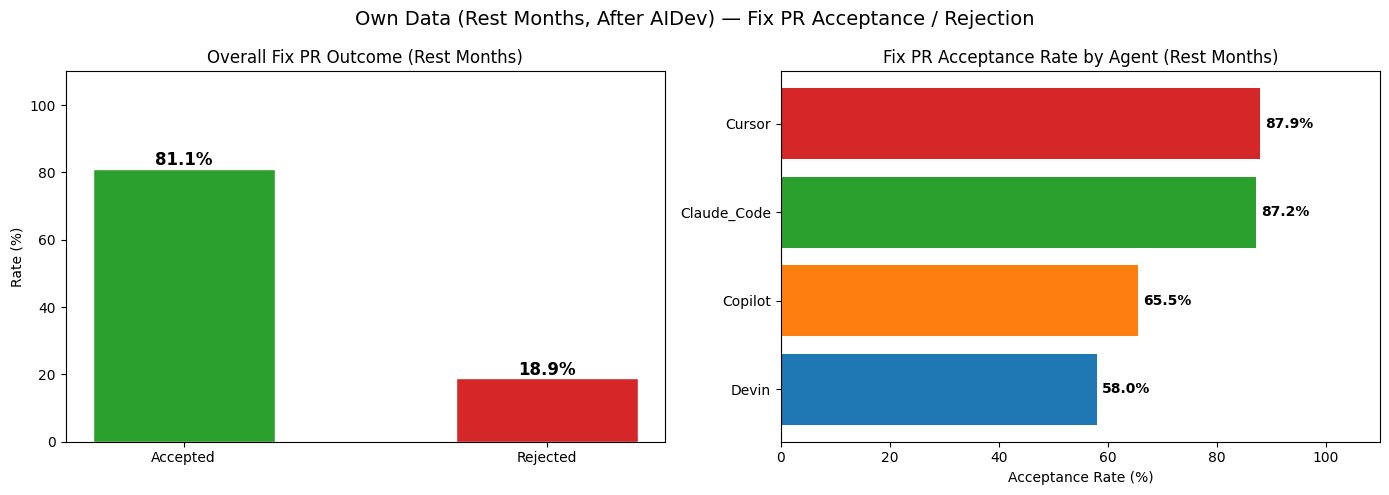


  -> Figure saved: results\rest_months_report_figures\acceptance_rejection_rate.png


In [10]:
# ── Acceptance & rejection rate bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall acceptance vs rejection
bars = axes[0].bar(["Accepted", "Rejected"], [total_rate, rejection_rate],
                   color=["#2ca02c", "#d62728"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [total_rate, rejection_rate]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Overall Fix PR Outcome (Rest Months)")
axes[0].set_ylim(0, 110)

# Right: per-agent acceptance rate
agents_sorted = agent_stats_df.sort_values("%Acceptance", ascending=True)
colors = sns.color_palette("tab10", len(agents_sorted))
bars2 = axes[1].barh(agents_sorted["Agent"], agents_sorted["%Acceptance"], color=colors)
for bar, val in zip(bars2, agents_sorted["%Acceptance"]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Acceptance Rate (%)")
axes[1].set_title("Fix PR Acceptance Rate by Agent (Rest Months)")
axes[1].set_xlim(0, 110)

fig.suptitle("Own Data (Rest Months, After AIDev) — Fix PR Acceptance / Rejection", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "acceptance_rejection_rate.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'acceptance_rejection_rate.png'}")

## Table: Acceptance and Merge Time Statistics

Same format as the AIDev and own-data (AIDev months) notebooks.

In [11]:
section("Table: Acceptance and Merge Time Statistics of Fix PRs")


def compute_row(label, df):
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged = df[df["merged_at"].notna()].copy()
    if len(merged):
        merged["hours"] = (
            pd.to_datetime(merged["merged_at"], utc=True)
            - pd.to_datetime(merged["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}h"]


rows = [compute_row("All 4 Agents", fix_prs)]
for agent_name in sorted(fix_prs["agent"].unique()):
    rows.append(compute_row(f"  {agent_name}", fix_prs[fix_prs["agent"] == agent_name]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
print("Acceptance and merge time statistics of fix PRs (own data, rest months).\n")
display(summary_df)

# Export as text
out(summary_df.to_string(index=False))


  Table: Acceptance and Merge Time Statistics of Fix PRs
Acceptance and merge time statistics of fix PRs (own data, rest months).



,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,All 4 Agents,"19,631","4,574","24,205",81.1%,1.61h
1,Claude_Code,"6,653",974,"7,627",87.2%,1.39h
2,Copilot,"3,883","2,041","5,924",65.5%,9.82h
3,Cursor,"8,564","1,175","9,739",87.9%,0.88h
4,Devin,531,384,915,58.0%,2.65h


     Category #Accepted #Rejected #Total %Acceptance Median Time to Merge
 All 4 Agents    19,631     4,574 24,205       81.1%                1.61h
  Claude_Code     6,653       974  7,627       87.2%                1.39h
      Copilot     3,883     2,041  5,924       65.5%                9.82h
       Cursor     8,564     1,175  9,739       87.9%                0.88h
        Devin       531       384    915       58.0%                2.65h


## Time to Merge Distribution

In [12]:
section("Time to Merge")

merged_prs = fix_prs[fix_prs["merged_at"].notna()].copy()
merged_prs["created_dt"] = pd.to_datetime(merged_prs["created_at"], utc=True)
merged_prs["merged_dt"] = pd.to_datetime(merged_prs["merged_at"], utc=True)
merged_prs["hours_to_merge"] = (merged_prs["merged_dt"] - merged_prs["created_dt"]).dt.total_seconds() / 3600

out(f"Merged fix PRs: {len(merged_prs):,}")
out(f"Overall median time to merge: {merged_prs['hours_to_merge'].median():.2f} hours")

out("\nPer-agent median time to merge:")
for agent_name in sorted(merged_prs["agent"].unique()):
    grp = merged_prs[merged_prs["agent"] == agent_name]
    med = grp["hours_to_merge"].median()
    out(f"  {agent_name:20s}  {med:.2f} hours  (n={len(grp):,})")


  Time to Merge
Merged fix PRs: 19,631
Overall median time to merge: 1.61 hours

Per-agent median time to merge:
  Claude_Code           1.39 hours  (n=6,653)
  Copilot               9.82 hours  (n=3,883)
  Cursor                0.88 hours  (n=8,564)
  Devin                 2.65 hours  (n=531)


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_8504\3213520013.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_ttm, labels=labels_ttm, patch_artist=True,


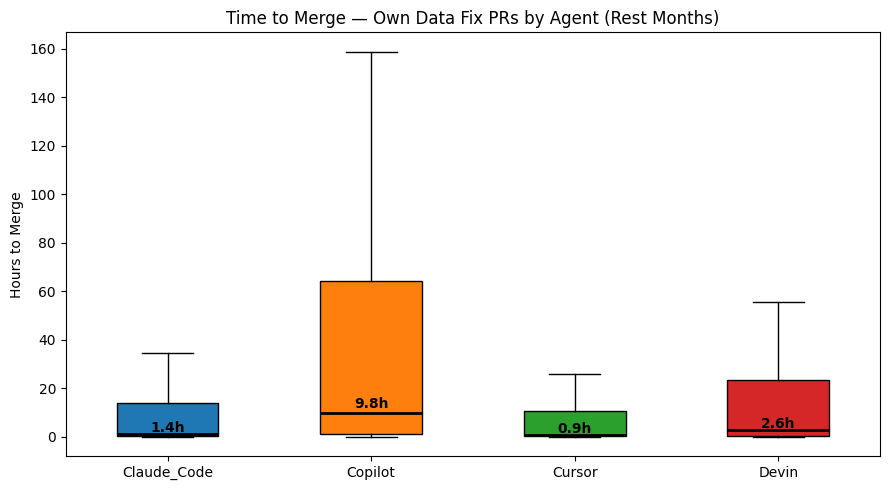

  -> Figure saved: results\rest_months_report_figures\time_to_merge_by_agent.png


In [13]:
# Time-to-merge box plot per agent
agents_ordered = sorted(merged_prs["agent"].unique())
data_ttm = []
labels_ttm = []
for agent_name in agents_ordered:
    grp = merged_prs[merged_prs["agent"] == agent_name]
    # Clip at 95th percentile for visualization
    vals = grp["hours_to_merge"].clip(upper=grp["hours_to_merge"].quantile(0.95)).values
    data_ttm.append(vals)
    labels_ttm.append(agent_name)

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_ttm, labels=labels_ttm, patch_artist=True,
                widths=0.5, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
palette = sns.color_palette("tab10", len(agents_ordered))
for patch, c in zip(bp["boxes"], palette):
    patch.set_facecolor(c)
for i, vals in enumerate(data_ttm):
    med = np.median(vals)
    ax.text(i + 1, med * 1.15 + 0.5, f"{med:.1f}h", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Hours to Merge")
ax.set_title("Time to Merge — Own Data Fix PRs by Agent (Rest Months)")
fig.tight_layout()
fig.savefig(FIG_DIR / "time_to_merge_by_agent.png", dpi=150)
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'time_to_merge_by_agent.png'}")

## Monthly Acceptance Rate Trends

In [14]:
section("Monthly Acceptance Rate")

fix_prs["created_month"] = pd.to_datetime(fix_prs["created_at"], utc=True).dt.to_period("M")

# Overall monthly
monthly_all = (
    fix_prs.groupby("created_month")["is_merged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "merged", "count": "total"})
    .reset_index()
)
monthly_all["acceptance_rate"] = monthly_all["merged"] / monthly_all["total"] * 100

out("Monthly acceptance rate (all 4 agents, rest months):")
out(f"{'Month':<12} {'Merged':>8} {'Total':>8} {'Rate':>8}")
out("-" * 40)
for _, row in monthly_all.iterrows():
    out(f"{str(row['created_month']):<12} {int(row['merged']):>8,} {int(row['total']):>8,} {row['acceptance_rate']:>7.1f}%")


  Monthly Acceptance Rate
Monthly acceptance rate (all 4 agents, rest months):
Month          Merged    Total     Rate
----------------------------------------
2025-07           170      199    85.4%
2025-08         2,686    3,468    77.5%
2025-09         2,669    3,281    81.3%
2025-10         2,566    3,149    81.5%
2025-11         2,493    3,165    78.8%
2025-12         2,503    2,992    83.7%
2026-01         2,978    3,639    81.8%
2026-02         3,566    4,312    82.7%


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_8504\591276068.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  fix_prs["created_month"] = pd.to_datetime(fix_prs["created_at"], utc=True).dt.to_period("M")


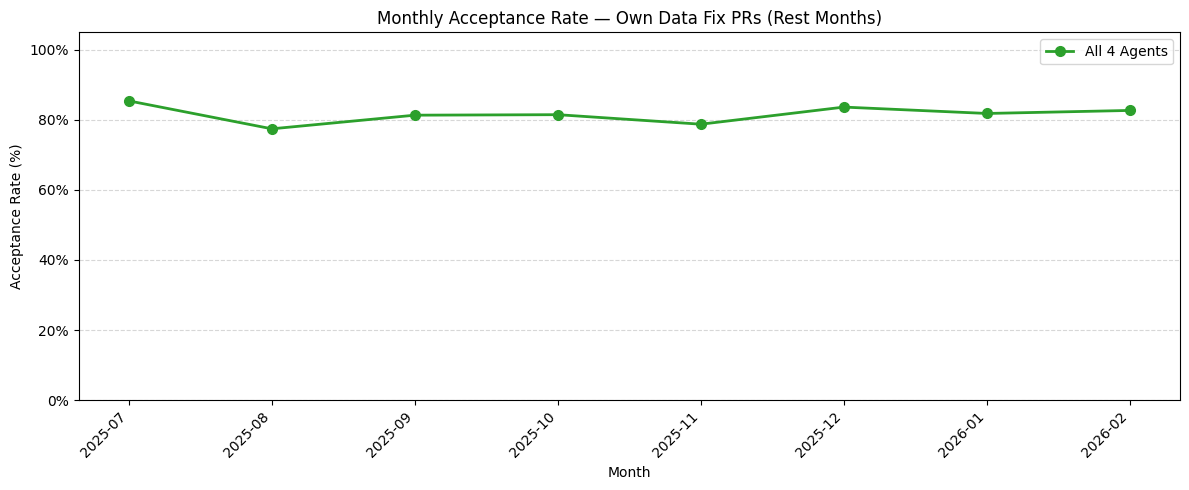


  -> Figure saved: results\rest_months_report_figures\monthly_acceptance_rate.png


In [15]:
# Monthly acceptance rate — overall line chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_all["created_month"].astype(str), monthly_all["acceptance_rate"],
        "o-", color="#2ca02c", linewidth=2, markersize=7, label="All 4 Agents")
ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Monthly Acceptance Rate — Own Data Fix PRs (Rest Months)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_acceptance_rate.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_acceptance_rate.png'}")

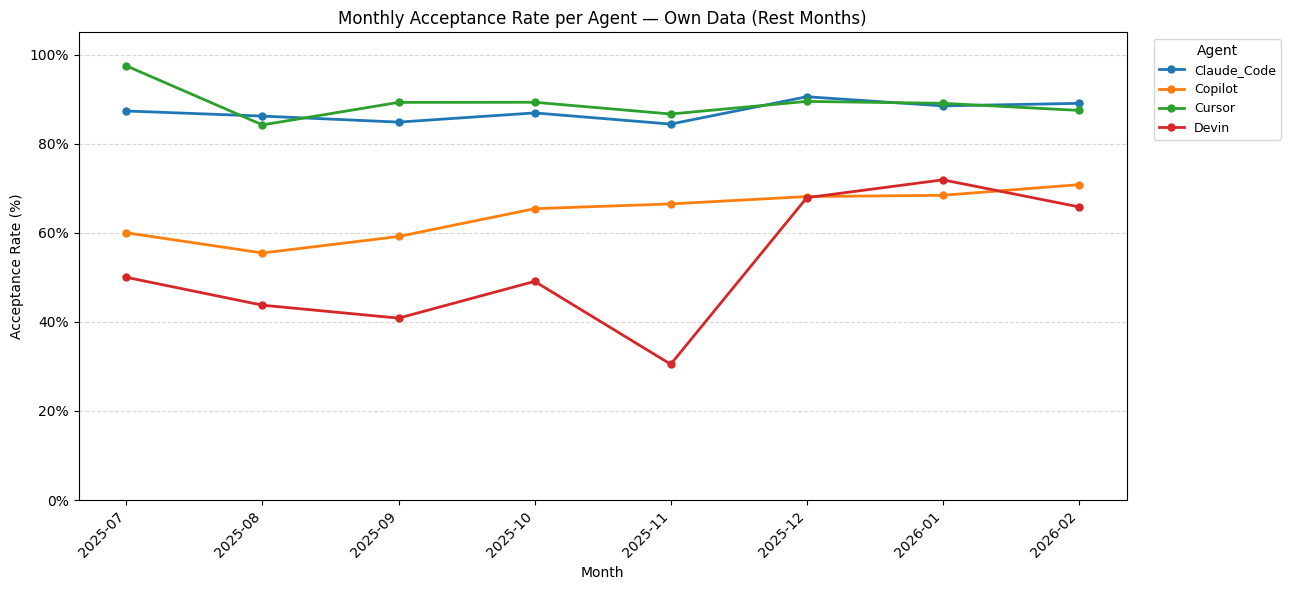

  -> Figure saved: results\rest_months_report_figures\monthly_acceptance_rate_per_agent.png


In [16]:
# Monthly acceptance rate — per agent
per_agent_monthly = (
    fix_prs.groupby(["created_month", "agent"])["is_merged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "merged", "count": "total"})
    .reset_index()
)
per_agent_monthly["acceptance_rate"] = per_agent_monthly["merged"] / per_agent_monthly["total"] * 100

agent_names = sorted(per_agent_monthly["agent"].unique())
palette = sns.color_palette("tab10", len(agent_names))

fig, ax = plt.subplots(figsize=(13, 6))
for agent_tool, color in zip(agent_names, palette):
    subset = per_agent_monthly[per_agent_monthly["agent"] == agent_tool].sort_values("created_month")
    ax.plot(
        subset["created_month"].astype(str),
        subset["acceptance_rate"],
        "o-", label=agent_tool, color=color, linewidth=2, markersize=5,
    )

ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Monthly Acceptance Rate per Agent — Own Data (Rest Months)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_acceptance_rate_per_agent.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'monthly_acceptance_rate_per_agent.png'}")

## Monthly Volume

In [17]:
section("Monthly Fix PR Volume")

monthly_vol = fix_prs.groupby(["created_month", "agent"]).size().unstack(fill_value=0)
monthly_vol["Total"] = monthly_vol.sum(axis=1)

out(f"{'Month':<12}" + "".join(f"{a:>14}" for a in monthly_vol.columns))
out("-" * (12 + 14 * len(monthly_vol.columns)))
for period in monthly_vol.index:
    row = monthly_vol.loc[period]
    out(f"{str(period):<12}" + "".join(f"{int(row[c]):>14,}" for c in monthly_vol.columns))


  Monthly Fix PR Volume
Month          Claude_Code       Copilot        Cursor         Devin         Total
----------------------------------------------------------------------------------
2025-07                 79            35            79             6           199
2025-08              1,130           759         1,483            96         3,468
2025-09              1,168           578         1,464            71         3,281
2025-10              1,016           743         1,280           110         3,149
2025-11                949           904         1,230            82         3,165
2025-12                994           728         1,133           137         2,992
2026-01                938         1,067         1,417           217         3,639
2026-02              1,353         1,110         1,653           196         4,312


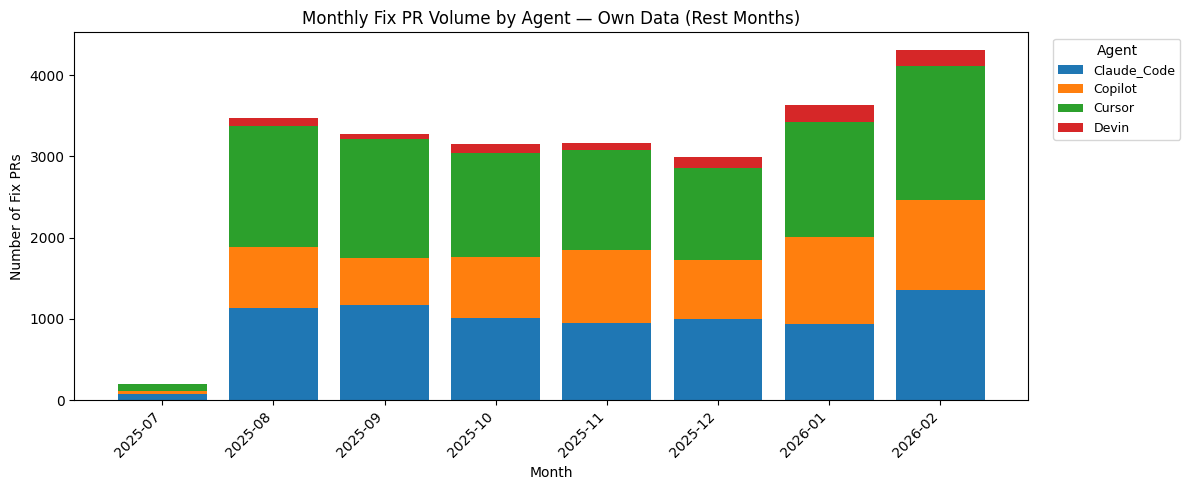


  -> Figure saved: results\rest_months_report_figures\monthly_volume_by_agent.png


In [18]:
# Monthly volume stacked bar chart
fig, ax = plt.subplots(figsize=(12, 5))
agent_cols = [c for c in monthly_vol.columns if c != "Total"]
palette_vol = sns.color_palette("tab10", len(agent_cols))
months_str = [str(p) for p in monthly_vol.index]

bottom = np.zeros(len(months_str))
for agent_name, color in zip(agent_cols, palette_vol):
    vals = monthly_vol[agent_name].values.astype(float)
    ax.bar(months_str, vals, bottom=bottom, label=agent_name, color=color)
    bottom += vals

ax.set_xlabel("Month")
ax.set_ylabel("Number of Fix PRs")
ax.set_title("Monthly Fix PR Volume by Agent — Own Data (Rest Months)")
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_volume_by_agent.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_volume_by_agent.png'}")

## Top Repositories

In [19]:
section("Top 15 Repositories by Fix PRs")

top_repos = fix_prs["repo_name"].value_counts().head(15)
out(f"{'Repo':<55} {'Total':>7} {'Merged':>8} {'Rate':>8}")
out("-" * 80)
for repo, cnt in top_repos.items():
    repo_fix = fix_prs[fix_prs["repo_name"] == repo]
    m = repo_fix["is_merged"].sum()
    r = m / cnt * 100 if cnt else 0
    out(f"  {repo:53s} {cnt:>7,} {m:>8,} {r:>7.1f}%")


  Top 15 Repositories by Fix PRs
Repo                                                      Total   Merged     Rate
--------------------------------------------------------------------------------
  getsentry/sentry                                          713      590    82.7%
  promptfoo/promptfoo                                       567      522    92.1%
  BerriAI/litellm                                           412      347    84.2%
  freenet/freenet-core                                      405      357    88.1%
  novuhq/novu                                               380      356    93.7%
  microsoft/vscode                                          367      154    42.0%
  langfuse/langfuse                                         360      344    95.6%
  jdx/mise                                                  313      301    96.2%
  PrefectHQ/prefect                                         303      254    83.8%
  sst/opencode                                              299  

## Comparison: AIDev Months vs Rest Months (Own Data)

Load own-data AIDev-months acceptance rates and compare with rest months.

In [20]:
section("Comparison: AIDev Months vs Rest Months (Own Data)")

# Load own data for AIDev months (the complement of the current dataset)
print("Loading own data for AIDev-months period ...")
own_full = pd.read_parquet(f"{HF_BASE}/fix_prs_only.parquet")
own_full = own_full[(own_full["source"] == "agent") & (own_full["agent"].isin(AGENTS_STUDIED))].copy()
own_full["created_dt"] = pd.to_datetime(own_full["created_at"], utc=True)
own_aidev_months = own_full[
    (own_full["created_dt"] <= AIDEV_MAX) & (own_full["state"] == "closed")
].copy()
own_aidev_months["is_merged"] = own_aidev_months["merged_at"].notna()
del own_full  # free memory

# Build comparison table
out(f"{'Agent':<20} {'AIDev-Mo #':>12} {'AIDev-Mo %Acc':>15} {'Rest-Mo #':>12} {'Rest-Mo %Acc':>15} {'Diff':>8}")
out("-" * 85)

comparison_rows = []
for agent_name in sorted(AGENTS_STUDIED):
    # AIDev months
    a_grp = own_aidev_months[own_aidev_months["agent"] == agent_name]
    a_m, a_t, a_r = merge_rate(a_grp)
    # Rest months
    r_grp = fix_prs[fix_prs["agent"] == agent_name]
    r_m, r_t, r_r = merge_rate(r_grp)
    diff = r_r - a_r
    out(f"  {agent_name:18s} {a_t:>12,} {a_r:>14.1f}% {r_t:>12,} {r_r:>14.1f}% {diff:>+7.1f}pp")
    comparison_rows.append({"Agent": agent_name, "AIDev_Mo_Total": a_t, "AIDev_Mo_Acc%": a_r,
                            "Rest_Mo_Total": r_t, "Rest_Mo_Acc%": r_r, "Diff_pp": diff})

# Overall
a_m_all, a_t_all, a_r_all = merge_rate(own_aidev_months)
r_m_all, r_t_all, r_r_all = merge_rate(fix_prs)
diff_all = r_r_all - a_r_all
out(f"  {'ALL 4 AGENTS':18s} {a_t_all:>12,} {a_r_all:>14.1f}% {r_t_all:>12,} {r_r_all:>14.1f}% {diff_all:>+7.1f}pp")

comparison_df = pd.DataFrame(comparison_rows)
print("\n")
display(comparison_df)


  Comparison: AIDev Months vs Rest Months (Own Data)
Loading own data for AIDev-months period ...
Agent                  AIDev-Mo #   AIDev-Mo %Acc    Rest-Mo #    Rest-Mo %Acc     Diff
-------------------------------------------------------------------------------------
  Claude_Code               9,073           84.9%        7,627           87.2%    +2.3pp
  Copilot                   2,031           57.9%        5,924           65.5%    +7.6pp
  Cursor                   10,378           90.8%        9,739           87.9%    -2.9pp
  Devin                     1,270           41.7%          915           58.0%   +16.3pp
  ALL 4 AGENTS             22,752           82.8%       24,205           81.1%    -1.7pp




,Agent,AIDev_Mo_Total,AIDev_Mo_Acc%,Rest_Mo_Total,Rest_Mo_Acc%,Diff_pp
0,Claude_Code,9073,84.911275,7627,87.229579,2.318304
1,Copilot,2031,57.902511,5924,65.546928,7.644417
2,Cursor,10378,90.797842,9739,87.935106,-2.862735
3,Devin,1270,41.732283,915,58.032787,16.300503


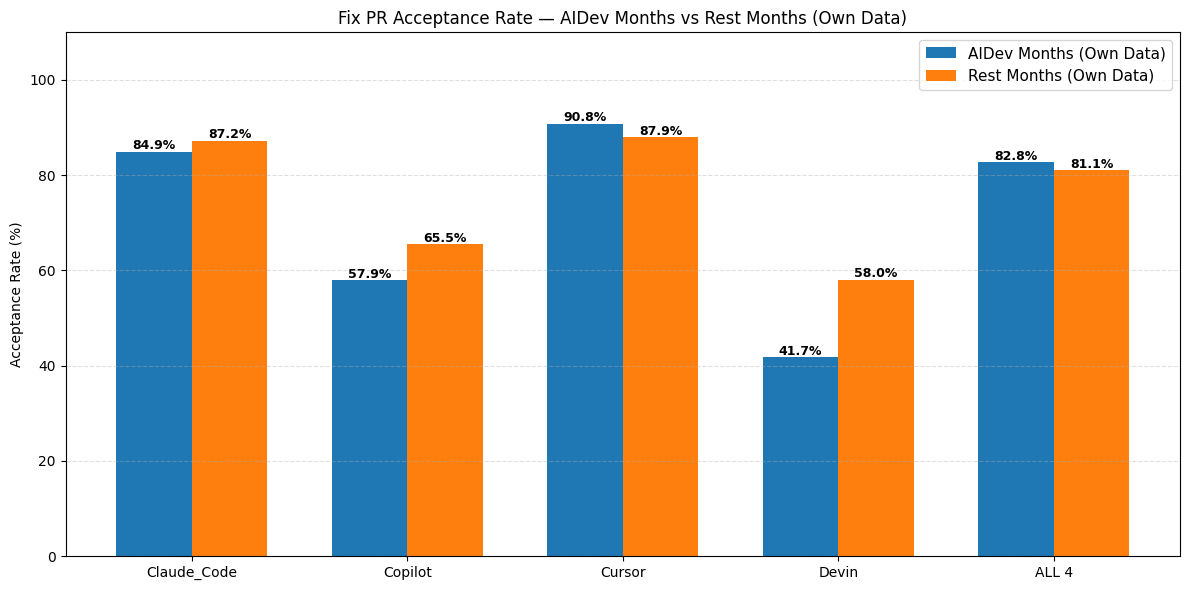


  -> Figure saved: results\rest_months_report_figures\aidev_months_vs_rest_months.png


In [21]:
# Side-by-side grouped bar chart
agents_cmp = sorted(AGENTS_STUDIED) + ["ALL 4"]
aidev_mo_rates = [comparison_df.loc[comparison_df["Agent"] == a, "AIDev_Mo_Acc%"].values[0] for a in sorted(AGENTS_STUDIED)] + [a_r_all]
rest_mo_rates  = [comparison_df.loc[comparison_df["Agent"] == a, "Rest_Mo_Acc%"].values[0]  for a in sorted(AGENTS_STUDIED)] + [r_r_all]

x = np.arange(len(agents_cmp))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, aidev_mo_rates, width, label="AIDev Months (Own Data)", color="#1f77b4")
bars2 = ax.bar(x + width / 2, rest_mo_rates,  width, label="Rest Months (Own Data)", color="#ff7f0e")

for bar, val in zip(bars1, aidev_mo_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
for bar, val in zip(bars2, rest_mo_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Fix PR Acceptance Rate — AIDev Months vs Rest Months (Own Data)")
ax.set_xticks(x)
ax.set_xticklabels(agents_cmp)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
fig.savefig(FIG_DIR / "aidev_months_vs_rest_months.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'aidev_months_vs_rest_months.png'}")

## Save Report

In [22]:
REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nReport saved to {REPORT_PATH}")
print(f"Figures saved to {FIG_DIR}/")
print("Done!")


Report saved to results\rest_months_report.txt
Figures saved to results\rest_months_report_figures/
Done!
